# CH'27 — Hub-Level Demand Forecasting
### Celebal Technologies × VIT Vellore

**Objective:** Forecast daily `OrderVolume` for each hub for the future 42-day test window.

**Metric:** RMSLE.

This notebook uses:
- full historical demand, including closed days, to build correct calendar lags;
- leak-safe lag/rolling features;
- a 42-day **recursive time-series validation**;
- LightGBM trained on `log1p(OrderVolume)`;
- recursive forecasting for the real test period;
- forced zero predictions for planned closed hubs.


In [16]:
# ============================================================
# 1. SETUP
# ============================================================

import os
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

VALIDATION_HORIZON_DAYS = 42

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("LightGBM is not installed. Run: pip install lightgbm")

print("LightGBM available:", HAS_LGB)


LightGBM available: True


In [17]:
# ============================================================
# 2. LOAD DATA
# ============================================================

DATA_DIR = "."

PATH_TRAIN = os.path.join(DATA_DIR, "orders_train.csv")
PATH_TEST = os.path.join(DATA_DIR, "orders_test.csv")
PATH_HUB_META = os.path.join(DATA_DIR, "hub_metadata.csv")
PATH_SAMPLE_SUB = os.path.join(DATA_DIR, "sample_submission.csv")

train_raw = pd.read_csv(PATH_TRAIN, parse_dates=["Date"])
test_raw = pd.read_csv(PATH_TEST, parse_dates=["Date"])
hub_meta = pd.read_csv(PATH_HUB_META)
sample_sub = pd.read_csv(PATH_SAMPLE_SUB)

print("Train:", train_raw.shape)
print("Test :", test_raw.shape)
print("Hub  :", hub_meta.shape)
print("Sample:", sample_sub.shape)

print("\nTrain date:", train_raw["Date"].min().date(), "->", train_raw["Date"].max().date())
print("Test date :", test_raw["Date"].min().date(), "->", test_raw["Date"].max().date())
print("Hubs      :", train_raw["HubID"].nunique())


Train: (970379, 9)
Test : (46830, 8)
Hub  : (1115, 10)
Sample: (46830, 2)

Train date: 2013-01-01 -> 2015-06-19
Test date : 2015-06-20 -> 2015-07-31
Hubs      : 1115


In [18]:
# ============================================================
# 3. BASIC EDA / SANITY CHECKS
# ============================================================

print("Train missing values:")
display(train_raw.isna().sum())

print("\nTest missing values:")
display(test_raw.isna().sum())

print("\nHub metadata missing values:")
display(hub_meta.isna().sum())

print("\nTarget summary:")
display(train_raw["OrderVolume"].describe())

print("Zero-volume rows:", (train_raw["OrderVolume"] == 0).mean())
print("Closed rows:", (train_raw["IsOpen"] == 0).mean())
print("Zero volume while open:",
      ((train_raw["OrderVolume"] == 0) & (train_raw["IsOpen"] == 1)).sum())

print("\nTest IsOpen:")
print(test_raw["IsOpen"].value_counts())


Train missing values:


HubID                0
Weekday              0
Date                 0
OrderVolume          0
AppSessions          0
IsOpen               0
PromoActive          0
RegionalHoliday      0
SchoolClosureFlag    0
dtype: int64


Test missing values:


Id                   0
HubID                0
Weekday              0
Date                 0
IsOpen               0
PromoActive          0
RegionalHoliday      0
SchoolClosureFlag    0
dtype: int64


Hub metadata missing values:


HubID                         0
HubFormat                     0
AssortmentTier                0
CompetitorDistance            3
CompetitorOpenSinceMonth    354
CompetitorOpenSinceYear     354
LoyaltyProgram                0
LoyaltyProgramSinceWeek     544
LoyaltyProgramSinceYear     544
LoyaltyProgramInterval      544
dtype: int64


Target summary:


count    970379.000000
mean       5762.766017
std        3855.457183
min           0.000000
25%        3708.000000
50%        5736.000000
75%        7850.000000
max       38722.000000
Name: OrderVolume, dtype: float64

Zero-volume rows: 0.17140004060269234
Closed rows: 0.1713443922426186
Zero volume while open: 54

Test IsOpen:
IsOpen
1    40282
0     6548
Name: count, dtype: int64


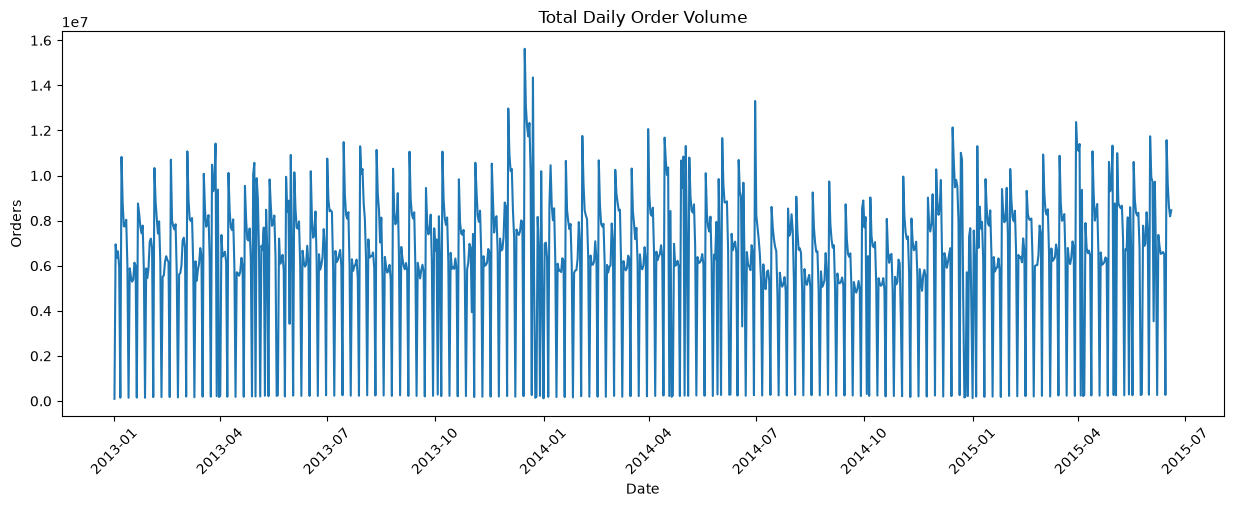

Weekday
1    7789.810555
2    6990.017140
3    6543.865120
4    6221.276095
5    6709.536510
6    5857.735540
7     202.175724
Name: AverageOrderVolume, dtype: float64

PromoActive
0    4395.015455
1    7969.052220
Name: AverageOrderVolume, dtype: float64

In [19]:
# Optional quick EDA

daily_total = train_raw.groupby("Date")["OrderVolume"].sum()

plt.figure(figsize=(15, 5))
plt.plot(daily_total.index, daily_total.values)
plt.title("Total Daily Order Volume")
plt.xlabel("Date")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

display(
    train_raw.groupby("Weekday")["OrderVolume"]
    .mean()
    .rename("AverageOrderVolume")
)

display(
    train_raw.groupby("PromoActive")["OrderVolume"]
    .mean()
    .rename("AverageOrderVolume")
)


In [20]:
# ============================================================
# 4. CLEAN HUB METADATA
# ============================================================

hub_meta_clean = hub_meta.copy()

# Competitor information
hub_meta_clean["HasCompetitor"] = (
    hub_meta_clean["CompetitorDistance"].notna().astype(int)
)

competitor_distance_fill = hub_meta_clean["CompetitorDistance"].max() * 2

hub_meta_clean["CompetitorDistance"] = (
    hub_meta_clean["CompetitorDistance"]
    .fillna(competitor_distance_fill)
)

hub_meta_clean["CompetitorOpenSinceMonth"] = (
    hub_meta_clean["CompetitorOpenSinceMonth"].fillna(0)
)

hub_meta_clean["CompetitorOpenSinceYear"] = (
    hub_meta_clean["CompetitorOpenSinceYear"].fillna(0)
)

# Loyalty information
hub_meta_clean["LoyaltyProgramSinceWeek"] = (
    hub_meta_clean["LoyaltyProgramSinceWeek"].fillna(0)
)

hub_meta_clean["LoyaltyProgramSinceYear"] = (
    hub_meta_clean["LoyaltyProgramSinceYear"].fillna(0)
)

hub_meta_clean["LoyaltyProgramInterval"] = (
    hub_meta_clean["LoyaltyProgramInterval"].fillna("None")
)

print("Remaining metadata NaNs:")
display(hub_meta_clean.isna().sum())


Remaining metadata NaNs:


HubID                       0
HubFormat                   0
AssortmentTier              0
CompetitorDistance          0
CompetitorOpenSinceMonth    0
CompetitorOpenSinceYear     0
LoyaltyProgram              0
LoyaltyProgramSinceWeek     0
LoyaltyProgramSinceYear     0
LoyaltyProgramInterval      0
HasCompetitor               0
dtype: int64

In [21]:
# ============================================================
# 5. IMPORTANT: MERGE METADATA BEFORE FILTERING CLOSED DAYS
# ============================================================
# We keep ALL historical rows here because closed days have real
# OrderVolume = 0 and must remain in the time-series history.
# We only remove closed rows later when fitting the demand model.

train_full = train_raw.merge(hub_meta_clean, on="HubID", how="left")
test_full = test_raw.merge(hub_meta_clean, on="HubID", how="left")

train_full = train_full.sort_values(["HubID", "Date"]).reset_index(drop=True)
test_full = test_full.sort_values(["HubID", "Date"]).reset_index(drop=True)

print(train_full.shape)
print(test_full.shape)


(970379, 19)
(46830, 18)


In [22]:
# ============================================================
# 6. CALENDAR FEATURES
# ============================================================

def add_calendar_features(df):
    df = df.copy()

    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["DayOfYear"] = df["Date"].dt.dayofyear
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["Quarter"] = df["Date"].dt.quarter

    # Weekday in the supplied data is 1..7.
    df["IsWeekend"] = df["Weekday"].isin([6, 7]).astype(int)

    df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

    df["Weekday_sin"] = np.sin(2 * np.pi * df["Weekday"] / 7)
    df["Weekday_cos"] = np.cos(2 * np.pi * df["Weekday"] / 7)

    df["DayOfYear_sin"] = np.sin(2 * np.pi * df["DayOfYear"] / 365.25)
    df["DayOfYear_cos"] = np.cos(2 * np.pi * df["DayOfYear"] / 365.25)

    df["DaysSinceStart"] = (
        df["Date"] - pd.Timestamp("2013-01-01")
    ).dt.days

    return df


train_full = add_calendar_features(train_full)
test_full = add_calendar_features(test_full)

display(
    train_full[
        ["Date", "Year", "Month", "Day", "WeekOfYear",
         "IsWeekend", "DaysSinceStart"]
    ].head()
)


,Date,Year,Month,Day,WeekOfYear,IsWeekend,DaysSinceStart
0,2013-01-01,2013,1,1,1,0,0
1,2013-01-02,2013,1,2,1,0,1
2,2013-01-03,2013,1,3,1,0,2
3,2013-01-04,2013,1,4,1,0,3
4,2013-01-05,2013,1,5,1,1,4


In [23]:
# ============================================================
# 7. HUB LIFECYCLE FEATURES
# ============================================================
# Fixed version: do NOT divide a pandas Timedelta by np.timedelta64(1, "M").
# Months are calculated using year/month arithmetic.

def add_hub_lifecycle_features(df):
    df = df.copy()

    comp_year = pd.to_numeric(
        df["CompetitorOpenSinceYear"], errors="coerce"
    )
    comp_month = pd.to_numeric(
        df["CompetitorOpenSinceMonth"], errors="coerce"
    )

    comp_valid = (comp_year > 0) & (comp_month > 0)

    months_since_comp = (
        (df["Date"].dt.year - comp_year) * 12
        + (df["Date"].dt.month - comp_month)
    )

    df["MonthsSinceCompetitorOpen"] = (
        months_since_comp
        .where(comp_valid, 0)
        .clip(lower=0)
        .fillna(0)
    )

    loyalty_year = pd.to_numeric(
        df["LoyaltyProgramSinceYear"], errors="coerce"
    ).fillna(0)

    loyalty_week = pd.to_numeric(
        df["LoyaltyProgramSinceWeek"], errors="coerce"
    ).fillna(0)

    current_week = (
        df["Date"].dt.isocalendar().year.astype(int) * 52
        + df["Date"].dt.isocalendar().week.astype(int)
    )

    loyalty_start = loyalty_year * 52 + loyalty_week

    df["WeeksSinceLoyaltyStart"] = np.where(
        (df["LoyaltyProgram"] == 1) & (loyalty_start > 0),
        (current_week - loyalty_start).clip(lower=0),
        0
    )

    month_map = {
        1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
        5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
        9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
    }

    month_name = df["Month"].map(month_map)

    df["LoyaltyIntervalActive"] = [
        int(
            month in str(interval).split(",")
            and str(interval) != "None"
        )
        for month, interval in zip(
            month_name,
            df["LoyaltyProgramInterval"]
        )
    ]

    return df


train_full = add_hub_lifecycle_features(train_full)
test_full = add_hub_lifecycle_features(test_full)

display(
    train_full[
        [
            "MonthsSinceCompetitorOpen",
            "WeeksSinceLoyaltyStart",
            "LoyaltyIntervalActive"
        ]
    ].describe()
)


,MonthsSinceCompetitorOpen,WeeksSinceLoyaltyStart,LoyaltyIntervalActive
count,970379.000000,970379.000000,970379.000000
mean,41.582139,55.356288,0.162072
std,65.042119,80.905749,0.368517
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,16.000000,0.000000,0.000000
75%,72.000000,106.000000,0.000000
max,1385.000000,306.000000,1.000000


In [24]:
# ============================================================
# 8. LEAK-FREE TRAINING HISTORY FEATURES
# ============================================================
# CRITICAL:
# These are created from the FULL historical dataset, including closed
# days. Closed days have OrderVolume = 0 and are valid historical demand.
#
# The model itself will later train only on IsOpen == 1 rows.

def add_training_history_features(df):
    df = df.sort_values(["HubID", "Date"]).copy()

    g = df.groupby("HubID")["OrderVolume"]

    lag_days = [
        1, 2, 3, 7, 14, 21, 28,
        35, 42, 56, 84,
        364, 365, 371, 728
    ]

    for lag in lag_days:
        df[f"Lag_{lag}"] = g.shift(lag)

    shifted = g.shift(1)

    for w in [7, 14, 28, 56]:
        df[f"RollMean_{w}"] = (
            shifted.groupby(df["HubID"])
            .rolling(w, min_periods=3)
            .mean()
            .reset_index(level=0, drop=True)
        )

        df[f"RollStd_{w}"] = (
            shifted.groupby(df["HubID"])
            .rolling(w, min_periods=3)
            .std()
            .reset_index(level=0, drop=True)
        )

    # Same weekday recent averages.
    # Because the data is daily and sorted by hub/date, these are
    # equivalent to useful weekly seasonal history features.
    df["SameWeekday_Lag_7"] = df["Lag_7"]
    df["SameWeekday_Lag_14"] = df["Lag_14"]
    df["SameWeekday_Lag_21"] = df["Lag_21"]
    df["SameWeekday_Lag_28"] = df["Lag_28"]

    return df


train_full = add_training_history_features(train_full)

hist_cols = [
    c for c in train_full.columns
    if c.startswith(("Lag_", "RollMean_", "RollStd_", "SameWeekday_"))
]

print("Historical features:", len(hist_cols))
print(hist_cols)


Historical features: 27
['Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'Lag_14', 'Lag_21', 'Lag_28', 'Lag_35', 'Lag_42', 'Lag_56', 'Lag_84', 'Lag_364', 'Lag_365', 'Lag_371', 'Lag_728', 'RollMean_7', 'RollStd_7', 'RollMean_14', 'RollStd_14', 'RollMean_28', 'RollStd_28', 'RollMean_56', 'RollStd_56', 'SameWeekday_Lag_7', 'SameWeekday_Lag_14', 'SameWeekday_Lag_21', 'SameWeekday_Lag_28']


In [25]:
# ============================================================
# 9. TARGET + TRAINING ROWS
# ============================================================

train_full["LogOrderVolume"] = np.log1p(train_full["OrderVolume"])

# Do not train the demand model on planned closed hubs.
# They will be forced to zero at prediction time.
train_model = train_full[train_full["IsOpen"] == 1].copy()

print("All historical rows:", len(train_full))
print("Open rows used for demand model:", len(train_model))


All historical rows: 970379
Open rows used for demand model: 804110


In [26]:
# ============================================================
# 10. FEATURE LIST
# ============================================================

categorical_features = [
    "HubID",
    "Weekday",
    "HubFormat",
    "AssortmentTier",
    "PromoActive",
    "RegionalHoliday",
    "SchoolClosureFlag",
    "LoyaltyProgram",
    "HasCompetitor",
    "IsWeekend",
    "LoyaltyIntervalActive",
]

numeric_features = [
    "Year",
    "Month",
    "Day",
    "DayOfYear",
    "WeekOfYear",
    "Quarter",
    "DaysSinceStart",
    "Month_sin",
    "Month_cos",
    "Weekday_sin",
    "Weekday_cos",
    "DayOfYear_sin",
    "DayOfYear_cos",
    "CompetitorDistance",
    "MonthsSinceCompetitorOpen",
    "WeeksSinceLoyaltyStart",
] + hist_cols

feature_cols = categorical_features + numeric_features
target_col = "LogOrderVolume"

# Use a common category definition across train and test.
for c in categorical_features:
    all_values = pd.concat(
        [train_full[c].astype(str), test_full[c].astype(str)],
        ignore_index=True
    ).unique()

    train_full[c] = pd.Categorical(
        train_full[c].astype(str),
        categories=all_values
    )

    test_full[c] = pd.Categorical(
        test_full[c].astype(str),
        categories=all_values
    )

    train_model[c] = train_full.loc[train_model.index, c]

print("Number of features:", len(feature_cols))
print(feature_cols)


Number of features: 54
['HubID', 'Weekday', 'HubFormat', 'AssortmentTier', 'PromoActive', 'RegionalHoliday', 'SchoolClosureFlag', 'LoyaltyProgram', 'HasCompetitor', 'IsWeekend', 'LoyaltyIntervalActive', 'Year', 'Month', 'Day', 'DayOfYear', 'WeekOfYear', 'Quarter', 'DaysSinceStart', 'Month_sin', 'Month_cos', 'Weekday_sin', 'Weekday_cos', 'DayOfYear_sin', 'DayOfYear_cos', 'CompetitorDistance', 'MonthsSinceCompetitorOpen', 'WeeksSinceLoyaltyStart', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'Lag_14', 'Lag_21', 'Lag_28', 'Lag_35', 'Lag_42', 'Lag_56', 'Lag_84', 'Lag_364', 'Lag_365', 'Lag_371', 'Lag_728', 'RollMean_7', 'RollStd_7', 'RollMean_14', 'RollStd_14', 'RollMean_28', 'RollStd_28', 'RollMean_56', 'RollStd_56', 'SameWeekday_Lag_7', 'SameWeekday_Lag_14', 'SameWeekday_Lag_21', 'SameWeekday_Lag_28']


In [27]:
# ============================================================
# 11. 42-DAY TIME SPLIT
# ============================================================

cutoff_date = (
    train_full["Date"].max()
    - pd.Timedelta(days=VALIDATION_HORIZON_DAYS)
)

train_dates = train_full.loc[
    train_full["Date"] <= cutoff_date, "Date"
]

valid_dates = train_full.loc[
    train_full["Date"] > cutoff_date, "Date"
].drop_duplicates().sort_values()

print(
    "Training period:",
    train_dates.min().date(),
    "->",
    train_dates.max().date()
)

print(
    "Validation period:",
    valid_dates.min().date(),
    "->",
    valid_dates.max().date()
)

print("Validation days:", len(valid_dates))


Training period: 2013-01-01 -> 2015-05-08
Validation period: 2015-05-09 -> 2015-06-19
Validation days: 42


In [28]:
# ============================================================
# 12. TRAIN / VALIDATION MATRICES
# ============================================================

fit_mask = (
    (train_full["Date"] <= cutoff_date)
    & (train_full["IsOpen"] == 1)
)

valid_mask = (
    (train_full["Date"] > cutoff_date)
    & (train_full["IsOpen"] == 1)
)

X_train = train_full.loc[fit_mask, feature_cols]
y_train = train_full.loc[fit_mask, target_col]

X_valid = train_full.loc[valid_mask, feature_cols]
y_valid = train_full.loc[valid_mask, target_col]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

X_train: (766637, 54)
y_train: (766637,)
X_valid: (37473, 54)
y_valid: (37473,)


In [29]:
# ============================================================
# 12. TRAIN / VALIDATION MATRICES
# ============================================================

fit_mask = (
    (train_full["Date"] <= cutoff_date)
    & (train_full["IsOpen"] == 1)
)

valid_mask = (
    (train_full["Date"] > cutoff_date)
    & (train_full["IsOpen"] == 1)
)

X_train = train_full.loc[fit_mask, feature_cols]
y_train = train_full.loc[fit_mask, target_col]

X_valid = train_full.loc[valid_mask, feature_cols]
y_valid = train_full.loc[valid_mask, target_col]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

X_train: (766637, 54)
y_train: (766637,)
X_valid: (37473, 54)
y_valid: (37473,)


In [31]:
print("Current feature columns:")
print(feature_cols)

print("\nHistorical features:")
print(hist_cols)

print("\nNumber of features:", len(feature_cols))

Current feature columns:
['HubID', 'Weekday', 'HubFormat', 'AssortmentTier', 'PromoActive', 'RegionalHoliday', 'SchoolClosureFlag', 'LoyaltyProgram', 'HasCompetitor', 'IsWeekend', 'LoyaltyIntervalActive', 'Year', 'Month', 'Day', 'DayOfYear', 'WeekOfYear', 'Quarter', 'DaysSinceStart', 'Month_sin', 'Month_cos', 'Weekday_sin', 'Weekday_cos', 'DayOfYear_sin', 'DayOfYear_cos', 'CompetitorDistance', 'MonthsSinceCompetitorOpen', 'WeeksSinceLoyaltyStart', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'Lag_14', 'Lag_21', 'Lag_28', 'Lag_35', 'Lag_42', 'Lag_56', 'Lag_84', 'Lag_364', 'Lag_365', 'Lag_371', 'Lag_728', 'RollMean_7', 'RollStd_7', 'RollMean_14', 'RollStd_14', 'RollMean_28', 'RollStd_28', 'RollMean_56', 'RollStd_56', 'SameWeekday_Lag_7', 'SameWeekday_Lag_14', 'SameWeekday_Lag_21', 'SameWeekday_Lag_28']

Historical features:
['Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'Lag_14', 'Lag_21', 'Lag_28', 'Lag_35', 'Lag_42', 'Lag_56', 'Lag_84', 'Lag_364', 'Lag_365', 'Lag_371', 'Lag_728', 'RollMean_7', 'RollStd_7

In [32]:
# ============================================================
# 13. BEST LIGHTGBM MODEL
# ============================================================

best_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=1800,
    learning_rate=0.05,
    num_leaves=128,
    min_child_samples=50,
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=1,
    lambda_l2=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

print("Training best LightGBM model...")

best_model.fit(
    X_train,
    y_train,
    categorical_feature=categorical_features
)

print("Model training completed.")

# Validation prediction
valid_pred_log = best_model.predict(X_valid)

validation_rmsle = np.sqrt(
    np.mean(
        (y_valid.values - valid_pred_log) ** 2
    )
)

print("=" * 60)
print("VALIDATION RMSLE")
print("=" * 60)
print(f"{validation_rmsle:.6f}")

Training best LightGBM model...
Model training completed.
VALIDATION RMSLE
0.117065


In [33]:
# ============================================================
# 14. FINAL MODEL — TRAIN ON ALL TRAINING DATA
# ============================================================

print("Training final model on all training data...")

final_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=1800,
    learning_rate=0.05,
    num_leaves=128,
    min_child_samples=50,
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=1,
    lambda_l2=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

X_full = train_full[feature_cols]
y_full = train_full[target_col]

final_model.fit(
    X_full,
    y_full,
    categorical_feature=categorical_features
)

print("FINAL MODEL TRAINED.")

Training final model on all training data...
FINAL MODEL TRAINED.


In [35]:
# ============================================================
# 15. BUILD MISSING TEST HISTORICAL FEATURES
# ============================================================

print("Building historical features for test set...")

# Sort
train_hist = train_full[["HubID", "Date", "OrderVolume"]].copy()
train_hist = train_hist.sort_values(["HubID", "Date"])

test_hist = test_full[["HubID", "Date"]].copy()
test_hist = test_hist.sort_values(["HubID", "Date"])

# ------------------------------------------------------------
# Lag features
# ------------------------------------------------------------

lag_days = [
    1, 2, 3, 7, 14, 21, 28, 35, 42, 56,
    84, 364, 365, 371, 728
]

for lag in lag_days:

    source = train_hist[["HubID", "Date", "OrderVolume"]].copy()

    source["Date"] = source["Date"] + pd.Timedelta(days=lag)

    source = source.rename(
        columns={"OrderVolume": f"Lag_{lag}"}
    )

    test_full = test_full.merge(
        source[["HubID", "Date", f"Lag_{lag}"]],
        on=["HubID", "Date"],
        how="left"
    )

# ------------------------------------------------------------
# Rolling features
# ------------------------------------------------------------

for w in [7, 14, 28, 56]:

    temp = train_hist.copy()

    temp["Date"] = temp["Date"] + pd.Timedelta(days=1)

    temp = (
        temp.sort_values(["HubID", "Date"])
        .groupby("HubID")
        .rolling(
            w,
            on="Date",
            min_periods=3
        )["OrderVolume"]
        .agg(["mean", "std"])
        .reset_index()
    )

    temp = temp.rename(
        columns={
            "mean": f"RollMean_{w}",
            "std": f"RollStd_{w}"
        }
    )

    temp["Date"] = temp["Date"] + pd.Timedelta(days=w-1)

    test_full = test_full.merge(
        temp[
            ["HubID", "Date",
             f"RollMean_{w}",
             f"RollStd_{w}"]
        ],
        on=["HubID", "Date"],
        how="left"
    )

# ------------------------------------------------------------
# Same weekday lag features
# ------------------------------------------------------------

for lag in [7, 14, 21, 28]:

    source = train_hist[["HubID", "Date", "OrderVolume"]].copy()

    source["Date"] = source["Date"] + pd.Timedelta(days=lag)

    source = source.rename(
        columns={
            "OrderVolume": f"SameWeekday_Lag_{lag}"
        }
    )

    test_full = test_full.merge(
        source[
            ["HubID", "Date",
             f"SameWeekday_Lag_{lag}"]
        ],
        on=["HubID", "Date"],
        how="left"
    )

# ------------------------------------------------------------
# Fill missing historical values
# ------------------------------------------------------------

missing_hist = [
    c for c in hist_cols
    if c not in test_full.columns
]

print("Still missing feature columns:", missing_hist)

for col in hist_cols:

    if col not in test_full.columns:
        test_full[col] = np.nan

    # Hub-specific mean from training
    hub_mean_map = (
        train_full.groupby("HubID")[col]
        .mean()
    )

    test_full[col] = (
        test_full[col]
        .fillna(
            test_full["HubID"].map(hub_mean_map)
        )
    )

    # Global fallback
    test_full[col] = test_full[col].fillna(
        train_full[col].mean()
    )

print("Historical features ready.")

print(
    "Remaining NaNs:",
    test_full[hist_cols].isna().sum().sum()
)

Building historical features for test set...
Still missing feature columns: []
Historical features ready.
Remaining NaNs: 0


In [36]:
# ============================================================
# 15B. CHECK TEST FEATURES
# ============================================================

missing_features = [
    c for c in feature_cols
    if c not in test_full.columns
]

print("Missing features:", missing_features)
print("Test shape:", test_full.shape)

Missing features: []
Test shape: (46830, 62)


In [37]:
# ============================================================
# 16. PREDICT TEST
# ============================================================

print("Generating test predictions...")

X_test = test_full[feature_cols]

test_pred_log = final_model.predict(X_test)

# Convert from log1p scale to original OrderVolume
test_pred = np.expm1(test_pred_log)

# Prevent negative predictions
test_pred = np.maximum(test_pred, 0)

# Closed hubs should have zero orders
test_pred[test_full["IsOpen"].values == 0] = 0

print("Predictions generated:", len(test_pred))

print("\nPrediction statistics:")
print(pd.Series(test_pred).describe())

Generating test predictions...
Predictions generated: 46830

Prediction statistics:
count    46830.000000
mean      5289.468569
std       3094.689966
min          0.000000
25%       3899.183366
50%       5335.636561
75%       6932.606673
max      27457.658680
dtype: float64


In [38]:
# ============================================================
# 17. CREATE SUBMISSION
# ============================================================

submission = pd.DataFrame({
    "Id": test_full["Id"],
    "OrderVolume": test_pred
})

print("Submission shape:", submission.shape)

display(submission.head(10))

submission.to_csv("submission.csv", index=False)

print("\n========================================")
print("submission.csv CREATED SUCCESSFULLY")
print("========================================")

Submission shape: (46830, 2)


,Id,OrderVolume
0,1,4039.527470
1,1116,0.000000
2,2231,3682.759797
3,3346,3760.789259
4,4461,3553.994885
5,5576,2959.339493
6,6691,3683.482523
7,7806,4134.383254
8,8921,0.000000
9,10036,4841.397342



submission.csv CREATED SUCCESSFULLY
